In [5]:
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----------- ---------------------------- 2.6/9.5 MB 16.3 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 23.7 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 24.2 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 30.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 37.5 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")


In [2]:
accuracy_journey = pd.DataFrame([
    {"stage": "Permuted labels\n(undiscovered bug)", "classification_acc": 6.0},
    {"stage": "Round 1\nlabel fix",                    "classification_acc": 77.57},
    {"stage": "Round 2\n(allowlist bug found & fixed)", "classification_acc": 61.73},
])
accuracy_journey


,stage,classification_acc
0,Permuted labels\n(undiscovered bug),6.00
1,Round 1\nlabel fix,77.57
2,Round 2\n(allowlist bug found & fixed),61.73


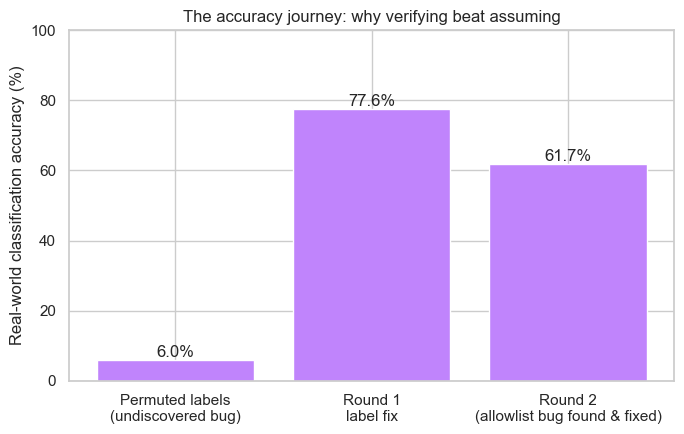

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(accuracy_journey["stage"], accuracy_journey["classification_acc"], color="#c084fc")
ax.set_ylabel("Real-world classification accuracy (%)")
ax.set_title("The accuracy journey: why verifying beat assuming")
ax.bar_label(bars, fmt="%.1f%%")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("accuracy_journey.png", dpi=150)
plt.show()


In [4]:
model_comparison = pd.DataFrame([
    {"model": "Nano",   "localization_recall": 79.34, "classification_acc": 61.73, "latency_ms": 101.5},
    {"model": "Medium", "localization_recall": 84.18, "classification_acc": 60.71, "latency_ms": 108.1},
    {"model": "Large",  "localization_recall": 82.65, "classification_acc": 62.76, "latency_ms": 120.6},
])
model_comparison

,model,localization_recall,classification_acc,latency_ms
0,Nano,79.34,61.73,101.5
1,Medium,84.18,60.71,108.1
2,Large,82.65,62.76,120.6


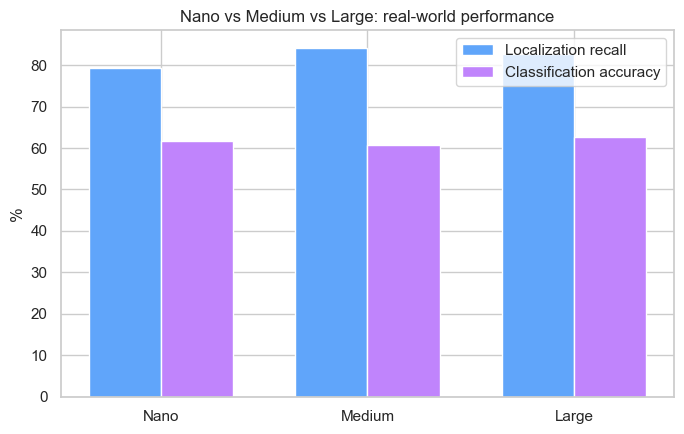

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(model_comparison))
width = 0.35

ax.bar(x - width/2, model_comparison["localization_recall"], width, label="Localization recall", color="#60a5fa")
ax.bar(x + width/2, model_comparison["classification_acc"], width, label="Classification accuracy", color="#c084fc")
ax.set_xticks(x)
ax.set_xticklabels(model_comparison["model"])
ax.set_ylabel("%")
ax.set_title("Nano vs Medium vs Large: real-world performance")
ax.legend()
plt.tight_layout()
plt.savefig("model_size_comparison.png", dpi=150)
plt.show()

In [9]:
classes = ["MCB", "RCD", "RCD_SI", "MAINBREAKER", "OVERSURGE", "OTHER"]

confusion_counts = pd.DataFrame(
    [
        [170, 11, 1, 10, 0, 2],   # true MCB
        [39, 39, 4, 0, 0, 1],     # true RCD
        [0, 1, 0, 0, 0, 0],       # true RCD_SI
        [14, 8, 1, 10, 0, 0],     # true MAINBREAKER
        [0, 0, 0, 1, 1, 0],       # true OVERSURGE
        [5, 2, 0, 0, 0, 10],      # true OTHER
    ],
    index=classes,
    columns=classes,
)
confusion_counts

,MCB,RCD,RCD_SI,MAINBREAKER,OVERSURGE,OTHER
MCB,170,11,1,10,0,2
RCD,39,39,4,0,0,1
RCD_SI,0,1,0,0,0,0
MAINBREAKER,14,8,1,10,0,0
OVERSURGE,0,0,0,1,1,0
OTHER,5,2,0,0,0,10


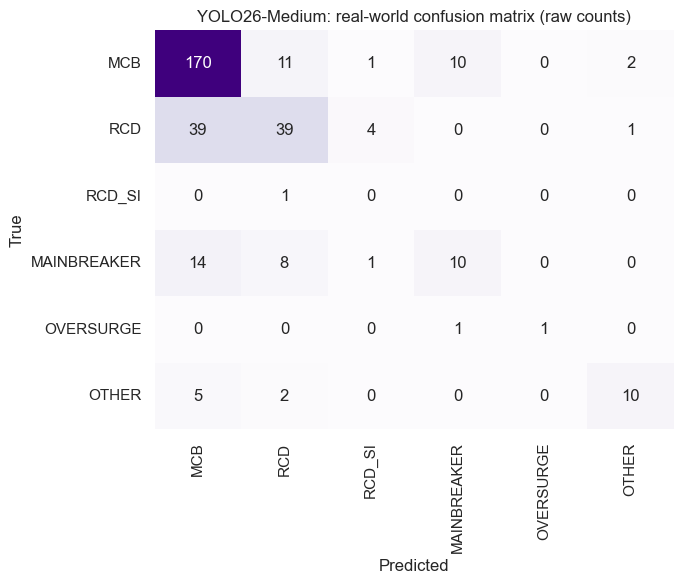

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(confusion_counts, annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("YOLO26-Medium: real-world confusion matrix (raw counts)")
plt.tight_layout()
plt.savefig("confusion_matrix_raw.png", dpi=150)
plt.show()

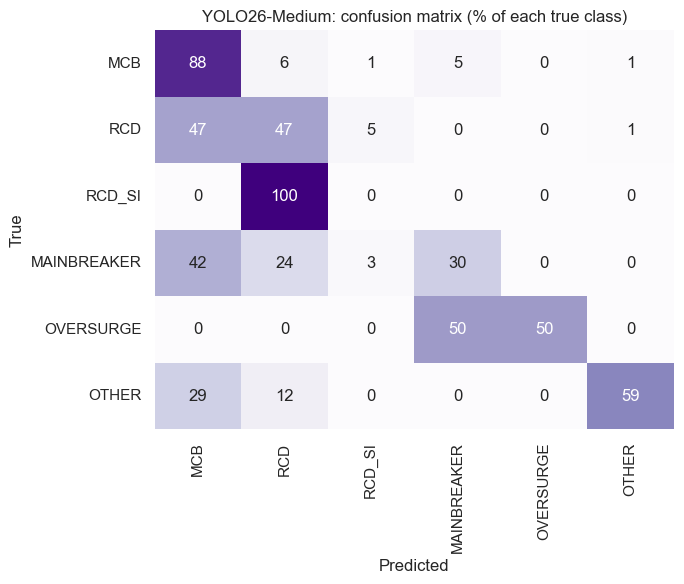

In [11]:
confusion_pct = confusion_counts.div(confusion_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(confusion_pct, annot=True, fmt=".0f", cmap="Purples", cbar=False, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("YOLO26-Medium: confusion matrix (% of each true class)")
plt.tight_layout()
plt.savefig("confusion_matrix_pct.png", dpi=150)
plt.show()

In [12]:
feature_ablation = pd.DataFrame([
    {"config": "YOLO Baseline\n(production)", "classification_acc": 61.73, "status": "baseline"},
    {"config": "YOLO + HMM\n(Markov chain)", "classification_acc": 55.87, "status": "cut"},
    {"config": "Two-Stage\nCrop Classifier", "classification_acc": 3.57, "status": "cut"},
    {"config": "Two-Stage + HMM", "classification_acc": 18.37, "status": "cut"},
])
feature_ablation

,config,classification_acc,status
0,YOLO Baseline\n(production),61.73,baseline
1,YOLO + HMM\n(Markov chain),55.87,cut
2,Two-Stage\nCrop Classifier,3.57,cut
3,Two-Stage + HMM,18.37,cut


C:\Users\PC GAMING\AppData\Local\Temp\ipykernel_21252\2607975995.py:16: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\PC GAMING\AppData\Local\Temp\ipykernel_21252\2607975995.py:17: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Arial.
  plt.savefig("feature_ablation.png", dpi=150)
c:\Users\PC GAMING\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


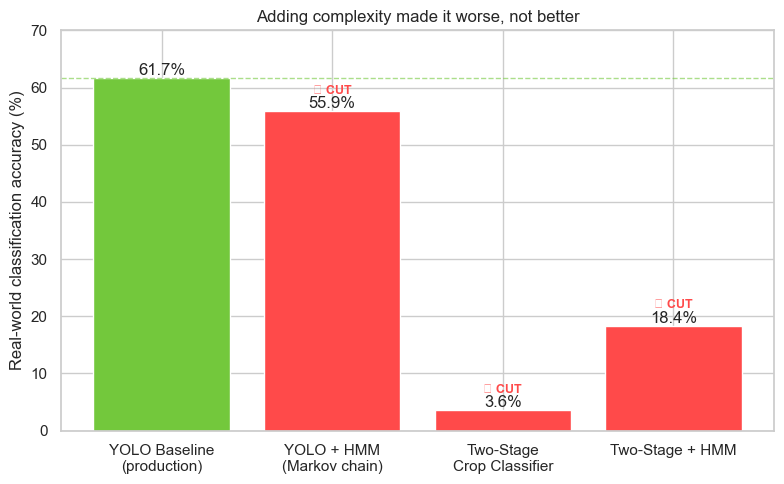

In [13]:
colors = feature_ablation["status"].map({"baseline": "#73c83c", "cut": "#ff4a4a"})

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(feature_ablation["config"], feature_ablation["classification_acc"], color=colors)
ax.axhline(61.73, color="#73c83c", linestyle="--", linewidth=1, alpha=0.6)
ax.bar_label(bars, fmt="%.1f%%")
ax.set_ylabel("Real-world classification accuracy (%)")
ax.set_title("Adding complexity made it worse, not better")
ax.set_ylim(0, 70)

for bar, status in zip(bars, feature_ablation["status"]):
    if status == "cut":
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, "✕ CUT",
                ha="center", color="#ff4a4a", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig("feature_ablation.png", dpi=150)
plt.show()


In [14]:
perbox = pd.read_csv("ablation_perbox_results.csv")
perbox.groupby("model")["correct"].agg(["mean", "count"])


,mean,count
model,,
Large,0.759259,324
Medium,0.721212,330
Nano,0.778135,311


In [15]:
import numpy as np

def bootstrap_accuracy_ci(df, model_name, n_boot=2000, seed=42):
    sub = df[df["model"] == model_name]
    images = sub["image"].unique()
    by_image = {img: sub[sub["image"] == img]["correct"].values for img in images}
    rng = np.random.default_rng(seed)

    boot_means = []
    for _ in range(n_boot):
        sampled_images = rng.choice(images, size=len(images), replace=True)
        pooled = np.concatenate([by_image[img] for img in sampled_images])
        boot_means.append(pooled.mean())

    point_estimate = sub["correct"].mean()
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    return point_estimate, lo, hi

for model in ["Nano", "Medium", "Large"]:
    point, lo, hi = bootstrap_accuracy_ci(perbox, model)
    print(f"{model:8s}: {point:.1%}  (95% CI: {lo:.1%} - {hi:.1%})")
    

Nano    : 77.8%  (95% CI: 67.4% - 86.0%)
Medium  : 72.1%  (95% CI: 59.0% - 83.6%)
Large   : 75.9%  (95% CI: 64.2% - 85.7%)
